# Yield Volatility — GARCH(1,1) Across the Curve

Rate vol is not constant. GARCH captures the clustering of large daily yield moves — the fact that volatile days beget volatile days. This notebook fits a GARCH(1,1) model to daily yield changes for all main Treasury tenors and surfaces:

1. **Rolling realised vol** — trailing 63-day (≈ 1 quarter) annualised std of daily changes
2. **GARCH conditional vol** — model-implied instantaneous vol, updated each day
3. **Current vol snapshot** — where each tenor sits vs its own history
4. **GARCH parameters** — persistence (α+β), long-run vol, and tail distribution per tenor

### Why yield changes, not yields?
Yields are non-stationary (unit root). GARCH is a model of variance, so we model **daily first differences** (Δy, in basis points). A 1bp daily move on the 10Y is the unit of analysis.

### Tenors
`DGS3MO` · `DGS1` · `DGS2` · `DGS5` · `DGS10` · `DGS30`

In [1]:
import importlib, sys, subprocess
for pkg in ("arch", "openpyxl"):
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

In [2]:
import warnings
from pathlib import Path
import sys

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

ROOT = Path("../..").resolve()
sys.path.insert(0, str(ROOT))

from tools import load_fred, Panel, Chart, NotebookOutput
from tools.palette import Palette, NAVY, GOLD, COPPER, COBALT, SLATE

OUT = NotebookOutput()   # → models/treasuries_spring26/output/

TENORS = {
    "DGS3MO": "3M",
    "DGS1":   "1Y",
    "DGS2":   "2Y",
    "DGS5":   "5Y",
    "DGS10":  "10Y",
    "DGS30":  "30Y",
}
COLORS = Palette.series(len(TENORS))
# Annualisation: daily yield changes, 252 trading days
ANN = np.sqrt(252)

## 1. Load Yields + Compute Daily Changes

In [3]:
# Load each tenor from the local FRED cache
raw = {}
for series_id, label in TENORS.items():
    s = load_fred(series_id).dropna()
    s.name = label
    raw[label] = s

yields = Panel(pd.concat(raw.values(), axis=1).sort_index().dropna(how="all"))

# Daily changes in basis points (bp).  Dropping NaNs created by .diff().
# Forward-fill the rare missing business day before differencing so we don't
# introduce spurious zero-change days.
changes_bp = Panel(yields.data.ffill().diff().dropna(how="all") * 100)
changes_bp.data.columns = list(TENORS.values())

print(f"Yields:  {yields.data.index[0].date()} → {yields.data.index[-1].date()}  ({len(yields)} obs)")
print(f"Changes: {changes_bp.data.index[0].date()} → {changes_bp.data.index[-1].date()}  ({len(changes_bp)} obs)\n")
print("Latest yields (%):")
print(yields.data.dropna().iloc[-1].rename("yield").to_frame().T.to_string(index=False))

Yields:  1962-01-02 → 2026-04-10  (16053 obs)
Changes: 1962-01-03 → 2026-04-10  (16052 obs)

Latest yields (%):
  3M  1Y   2Y   5Y  10Y  30Y
3.69 3.7 3.81 3.94 4.31 4.91


## 2. Rolling Realised Volatility

63-day trailing window (≈ one quarter), annualised. Gives the recent vol regime context before fitting GARCH.

Current 63-day rolling vol (annualised bp):

  3M       11.0 bp/yr
  1Y       25.4 bp/yr
  2Y       36.9 bp/yr
  5Y       39.4 bp/yr
  10Y      35.2 bp/yr
  30Y      31.9 bp/yr


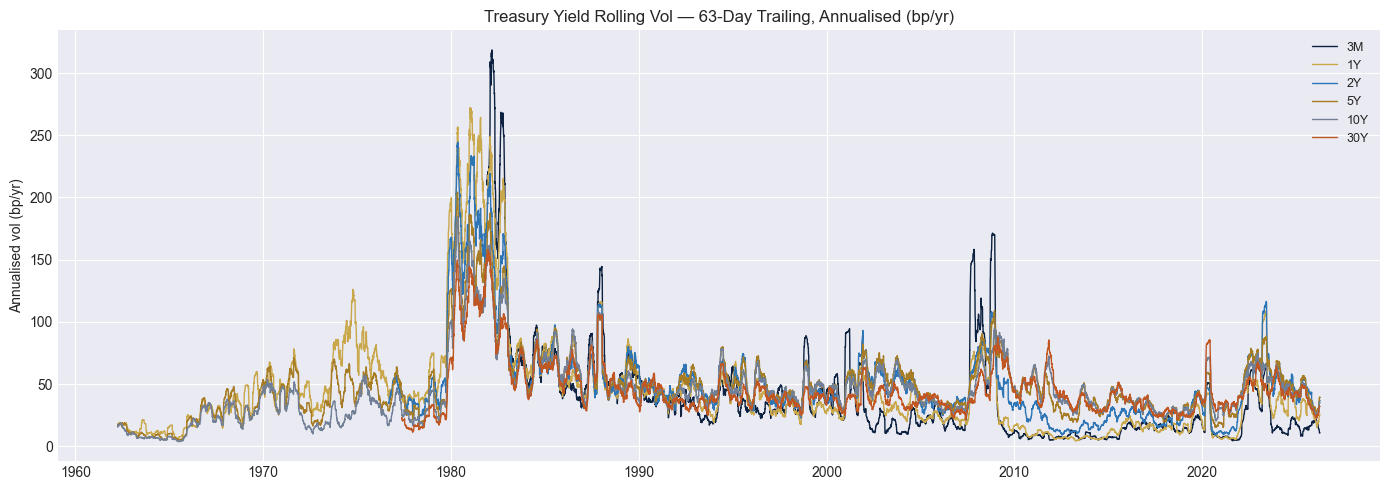

In [4]:
ROLL_WIN = 63   # trading days ≈ 1 quarter

# Rolling vol of daily bp changes, annualised (sqrt(252) * daily std)
rolling_vol = changes_bp.rolling_vol(window=ROLL_WIN, annualize=True)

# Current trailing vol per tenor
current_rolling = rolling_vol.data.dropna().iloc[-1]
print(f"Current {ROLL_WIN}-day rolling vol (annualised bp):\n")
for label, val in current_rolling.items():
    print(f"  {label:<5s}  {val:6.1f} bp/yr")

# -- Chart: rolling vol history for all tenors --------------------------------
Chart(1, 1, figsize=(14, 5)) \
    .time_series(
        rolling_vol,
        title=f"Treasury Yield Rolling Vol — {ROLL_WIN}-Day Trailing, Annualised (bp/yr)",
        ylabel="Annualised vol (bp/yr)",
    ) \
    .tight().save(OUT / "rolling_vol_history.png")

## 3. GARCH(1,1) — Fit All Tenors

$$\sigma_t^2 = \omega + \alpha \epsilon_{t-1}^2 + \beta \sigma_{t-1}^2$$

- **ω** — long-run variance floor
- **α** — reaction to yesterday's shock (ARCH term)
- **β** — persistence of variance from yesterday (GARCH term)
- **α + β** — total persistence; close to 1 means vol decays slowly after a shock

Fit with Student-t innovations to accommodate the fat tails typical of rate changes.

> **Note on tooling:** The GARCH fitting loop below is roughly 40 lines of boilerplate that repeats for every volatility model in this repo. A `tools/volatility.py` with a `GarchFit` class (wrapping `arch.arch_model`, storing results, exposing `.conditional_vol`, `.params`, `.forecast(h)`) would make this a 3-line call per tenor and enable reuse in macro-regime and portfolio notebooks.

In [5]:
from arch import arch_model

garch_results = {}   # label → arch ModelResult
cond_vol      = {}   # label → pd.Series of conditional vol (annualised bp/yr)

for label in TENORS.values():
    series = changes_bp.data[label].dropna()

    am = arch_model(series, vol="Garch", p=1, q=1, dist="t", rescale=False)
    res = am.fit(disp="off", show_warning=False)

    # Conditional vol: daily std in bp, annualised
    cv = res.conditional_volatility * ANN
    cv.name = label

    garch_results[label] = res
    cond_vol[label] = cv
    print(f"{label:<5s}  ω={res.params['omega']:.4f}  α={res.params['alpha[1]']:.4f}  "
          f"β={res.params['beta[1]']:.4f}  persist={res.params['alpha[1]']+res.params['beta[1]']:.4f}  "
          f"current vol={cv.iloc[-1]:.1f} bp/yr")

3M     ω=0.0432  α=0.1050  β=0.8950  persist=1.0000  current vol=20.3 bp/yr
1Y     ω=0.0196  α=0.0658  β=0.9342  persist=1.0000  current vol=57.3 bp/yr
2Y     ω=0.0580  α=0.0513  β=0.9487  persist=1.0000  current vol=81.0 bp/yr
5Y     ω=0.0104  α=0.0473  β=0.9527  persist=1.0000  current vol=85.9 bp/yr
10Y    ω=0.0038  α=0.0464  β=0.9536  persist=1.0000  current vol=74.8 bp/yr
30Y    ω=0.0788  α=0.0422  β=0.9570  persist=0.9992  current vol=67.6 bp/yr


## 4. GARCH Conditional Vol — Full History

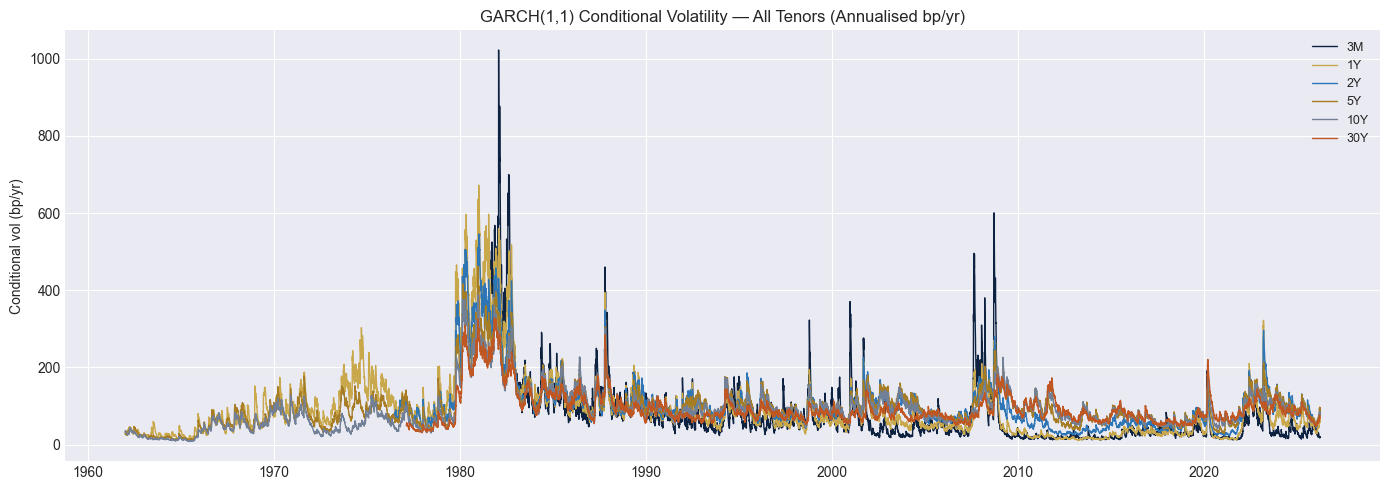

In [6]:
cond_vol_panel = Panel(pd.concat(cond_vol.values(), axis=1))

Chart(1, 1, figsize=(14, 5)) \
    .time_series(
        cond_vol_panel,
        title="GARCH(1,1) Conditional Volatility — All Tenors (Annualised bp/yr)",
        ylabel="Conditional vol (bp/yr)",
    ) \
    .tight().save(OUT / "garch_cond_vol_history.png")

## 5. Rolling vs GARCH — Side-by-Side (Last 5 Years)

Rolling vol is backward-looking with equal weight on all 63 days.  
GARCH decays faster on old shocks and reacts sharper to new ones — the difference shows how much of current vol is "stale carry" vs fresh regime.

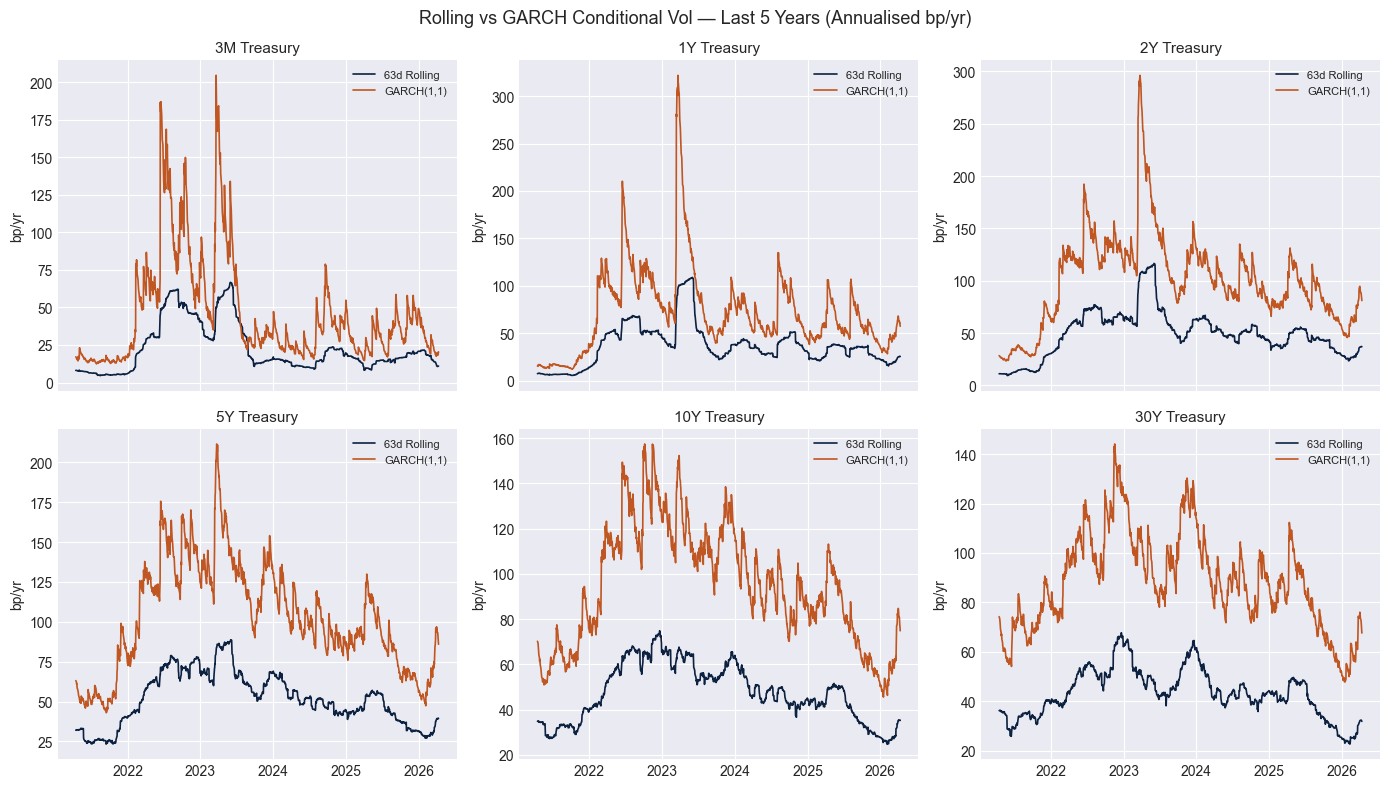

In [7]:
import matplotlib.pyplot as plt
from tools.palette import NAVY, COPPER

START_5Y = pd.Timestamp.today() - pd.DateOffset(years=5)
labels = list(TENORS.values())
n = len(labels)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows), sharex=True)
axes_flat = axes.flatten()

for i, label in enumerate(labels):
    ax = axes_flat[i]
    rv = rolling_vol.data[label].loc[START_5Y:]
    gv = cond_vol[label].loc[START_5Y:]

    ax.plot(rv.index, rv.values, color=NAVY,   linewidth=1.2, label=f"{ROLL_WIN}d Rolling")
    ax.plot(gv.index, gv.values, color=COPPER, linewidth=1.2, label="GARCH(1,1)")
    ax.set_title(f"{label} Treasury", fontsize=11)
    ax.set_ylabel("bp/yr")
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle("Rolling vs GARCH Conditional Vol — Last 5 Years (Annualised bp/yr)", fontsize=13)
plt.tight_layout()
fig.savefig(OUT / "rolling_vs_garch_grid.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Current Vol Snapshot — Where Are We Now?

Current GARCH vol vs each tenor's own history (percentile rank). A reading above the 80th percentile means vol is historically elevated.

       GARCH vol (bp/yr)  Pctile (vs history)  1Y mean (bp/yr)  All-time mean  All-time max  Rolling vol (bp/yr)
Tenor                                                                                                           
3M                  20.3                 14.3             32.8           75.9        1022.7                 11.0
1Y                  57.3                 40.7             57.7           90.9         672.4                 25.4
2Y                  81.0                 43.6             81.0          104.6         545.3                 36.9
5Y                  85.9                 48.4             79.7           97.3         462.0                 39.4
10Y                 74.8                 42.0             71.8           89.2         387.2                 35.2
30Y                 67.6                 24.0             71.7           94.4         328.5                 31.9


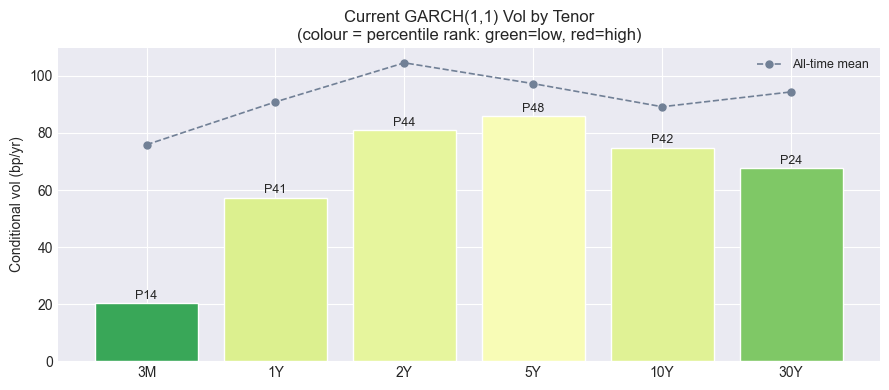

In [15]:
rows = []
for label in TENORS.values():
    full = cond_vol[label].dropna()
    current = full.iloc[-1]
    pctile = (full < current).mean() * 100
    cutoff_1y = full.index[-1] - pd.DateOffset(days=365)
    rows.append({
        "Tenor":               label,
        "GARCH vol (bp/yr)":   round(current, 1),
        "Pctile (vs history)": round(pctile, 1),
        "1Y mean (bp/yr)":     round(full[full.index >= cutoff_1y].mean(), 1),
        "All-time mean":       round(full.mean(), 1),
        "All-time max":        round(full.max(), 1),
        "Rolling vol (bp/yr)": round(rolling_vol.data[label].dropna().iloc[-1], 1),
    })

snapshot = pd.DataFrame(rows).set_index("Tenor")
print(snapshot.to_string())

# Bar chart: current GARCH vol by tenor with percentile colour coding
import matplotlib.pyplot as plt
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(9, 4))
pctiles = snapshot["Pctile (vs history)"].values / 100
colors_bar = [cm.RdYlGn_r(p) for p in pctiles]
bars = ax.bar(snapshot.index, snapshot["GARCH vol (bp/yr)"], color=colors_bar, edgecolor="white")
ax.plot(snapshot.index, snapshot["All-time mean"], "o--", color=SLATE,
        linewidth=1.2, markersize=5, label="All-time mean")
for bar, pct in zip(bars, snapshot["Pctile (vs history)"].values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"P{pct:.0f}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Conditional vol (bp/yr)")
ax.set_title("Current GARCH(1,1) Vol by Tenor\n(colour = percentile rank: green=low, red=high)")
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(OUT / "current_vol_snapshot.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. GARCH Parameter Summary

Persistence (α+β) near 1 → vol shocks die slowly (rate vol is "sticky").  
High α relative to β → vol reacts sharply to new shocks but mean-reverts quickly.  
Low ν (degrees of freedom) → fat-tailed rate changes.

In [16]:
param_rows = []
for label, res in garch_results.items():
    p = res.params
    alpha = p["alpha[1]"]
    beta  = p["beta[1]"]
    omega = p["omega"]
    nu    = p.get("nu", float("nan"))   # degrees of freedom (Student-t)
    # Long-run vol (unconditional): sqrt(omega / (1 - alpha - beta))
    lr_var = omega / max(1 - alpha - beta, 1e-8)
    lr_vol = np.sqrt(lr_var) * ANN
    param_rows.append({
        "Tenor":        label,
        "ω (omega)":    round(omega, 5),
        "α (ARCH)":     round(alpha, 4),
        "β (GARCH)":    round(beta,  4),
        "α+β persist":  round(alpha + beta, 4),
        "LR vol (bp/yr)": round(lr_vol, 1),
        "ν (t dof)":    round(nu, 2) if not np.isnan(nu) else "—",
    })

params_df = pd.DataFrame(param_rows).set_index("Tenor")
print(params_df.to_string())

       ω (omega)  α (ARCH)  β (GARCH)  α+β persist  LR vol (bp/yr)  ν (t dof)
Tenor                                                                        
3M       0.04318    0.1050     0.8950       1.0000         32987.5       4.07
1Y       0.01964    0.0658     0.9342       1.0000          8688.4       4.55
2Y       0.05798    0.0513     0.9487       1.0000         38224.3       4.92
5Y       0.01039    0.0473     0.9527       1.0000         16183.3       6.03
10Y      0.00383    0.0464     0.9536       1.0000          9825.6       6.75
30Y      0.07876    0.0422     0.9570       0.9992           153.7       7.54


## 8. Excel Export

In [17]:
wb = OUT.excel("yield_vol_garch.xlsx")

# Raw yields
wb.write("Yields", yields.data.reset_index().rename(columns={"index": "date"}))

# Daily changes (bp)
wb.write("Daily Changes (bp)", changes_bp.data.reset_index().rename(columns={"index": "date"}))

# Rolling vol history
wb.write("Rolling Vol", rolling_vol.data.reset_index().rename(columns={"index": "date"}))

# GARCH conditional vol history
wb.write("GARCH Cond Vol", cond_vol_panel.data.reset_index().rename(columns={"index": "date"}))

# Current snapshot
wb.write("Current Snapshot", snapshot.reset_index())

# GARCH parameters
wb.write("GARCH Params", params_df.reset_index())

wb.save()
print(f"Saved → {wb.path}")

Saved → C:\Users\btm74.000\Projects\qf_toolset\models\treasuries_spring26\output\yield_vol_garch.xlsx
